In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score,classification_report

Dataset used->https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download


In [3]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')


Understanding the Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Total Charges are object type instead of being a numeric data.So we convert it.

In [6]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

As churn has no relation with CustomerID we will drop it form df.

In [31]:
df=df.drop(columns='customerID',axis=1)

KeyError: "['customerID'] not found in axis"

Check the NA values present values in the dataset

In [8]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Imputing the Missing Values in Total charges with median of Total charges.As Median is best way to avoid effects of outlier by using mean or mode.

In [9]:
imputer=SimpleImputer(strategy='median')
df['TotalCharges']=pd.DataFrame(imputer.fit_transform(df[['TotalCharges']]))

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Separating numeric and object columns to apply preprocessing on them without dtype conflicts.

In [11]:
n_column=[]
o_column=[]
for column in df.columns:
  if df[column].dtype !='object':
    n_column.append(column)
  elif column!='customerID':
    o_column.append(column)

Label encoding the features

In [13]:
df = pd.get_dummies(df,dtype=int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 47 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender_Female                            7043 non-null   int64  
 5   gender_Male                              7043 non-null   int64  
 6   Partner_No                               7043 non-null   int64  
 7   Partner_Yes                              7043 non-null   int64  
 8   Dependents_No                            7043 non-null   int64  
 9   Dependents_Yes                           7043 non-null   int64  
 10  PhoneService_No                          7043 no

Here we drop most of the XXX_yes columns as they can be derived from XXX_no(for eg XXX_no=0 ==> XXX_yes=1 and vice versa). Also as XXX_no have other extensions like XXX_no_internet service we should keep the XXX_no feature.

In [15]:
df = df.drop(columns=['Churn_No','StreamingMovies_Yes','StreamingTV_Yes','PaperlessBilling_No','StreamingTV_Yes','TechSupport_Yes','DeviceProtection_Yes','OnlineBackup_Yes','OnlineSecurity_Yes','PhoneService_No','Dependents_No','Partner_No','gender_Female'], axis=1)

Confirmation to see if data has been dropped

In [16]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineBackup_No,OnlineBackup_No internet service,DeviceProtection_No,DeviceProtection_No internet service,TechSupport_No,TechSupport_No internet service,StreamingTV_No,StreamingTV_No internet service,StreamingMovies_No,StreamingMovies_No internet service,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,1,0,1


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineBackup_No,OnlineBackup_No internet service,DeviceProtection_No,DeviceProtection_No internet service,TechSupport_No,TechSupport_No internet service,StreamingTV_No,StreamingTV_No internet service,StreamingMovies_No,StreamingMovies_No internet service,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.504756,0.483033,0.299588,0.903166,0.481329,0.096834,0.421837,0.343746,0.439585,0.216669,0.496663,0.216669,0.438450,0.216669,0.439443,0.216669,0.493114,0.216669,0.398978,0.216669,0.395428,0.216669,0.550192,0.209144,0.240664,0.592219,0.219225,0.216101,0.335794,0.228880,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.500013,0.499748,0.458110,0.295752,0.499687,0.295752,0.493888,0.474991,0.496372,0.412004,0.500024,0.412004,0.496232,0.412004,0.496355,0.412004,0.499988,0.412004,0.489723,0.412004,0.488977,0.412004,0.497510,0.406726,0.427517,0.491457,0.413751,0.411613,0.472301,0.420141,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


To see the relation between the features

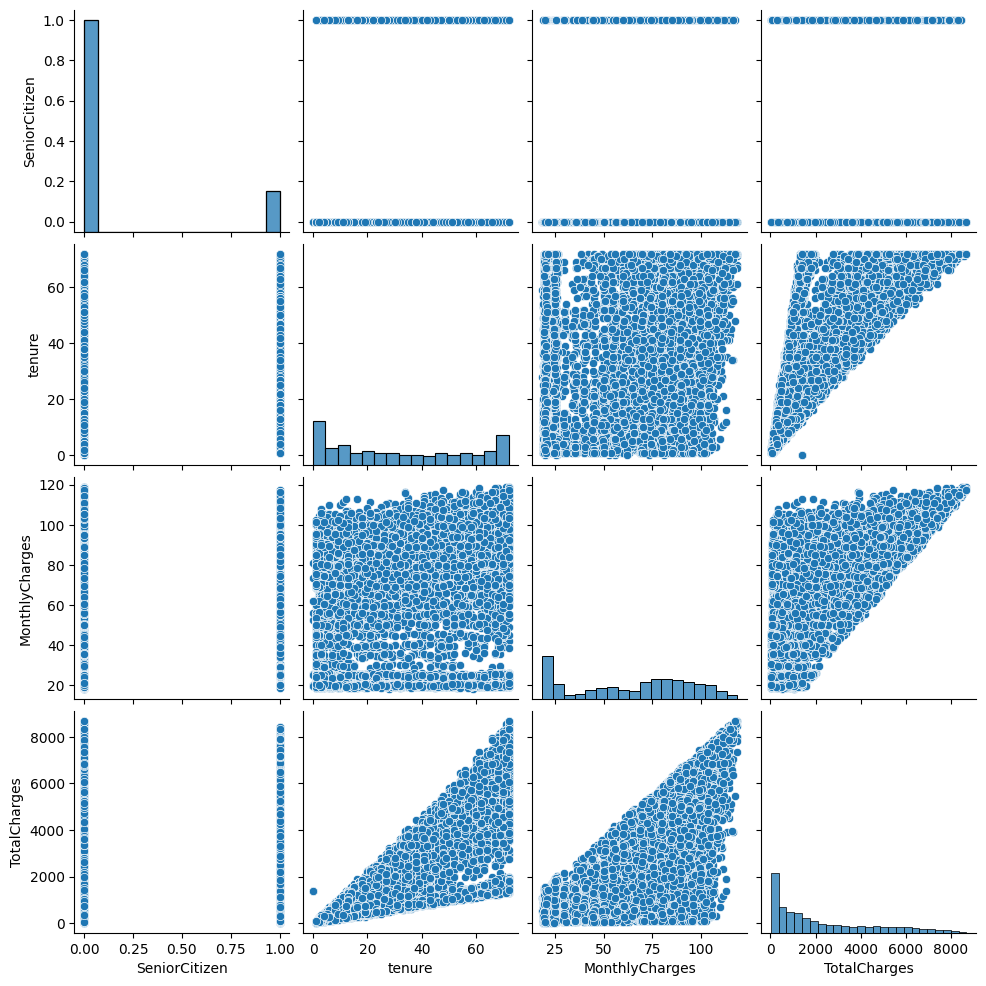

In [18]:
sns.pairplot(df[n_column])

relation bw most features is linear but varies too much.It can be fixed using Logarithmic scaling.

In [19]:
df[n_column]=np.log1p(df[n_column])

Here you can clearly see that the datapoint is much more closer to a linear relation tendency than before.

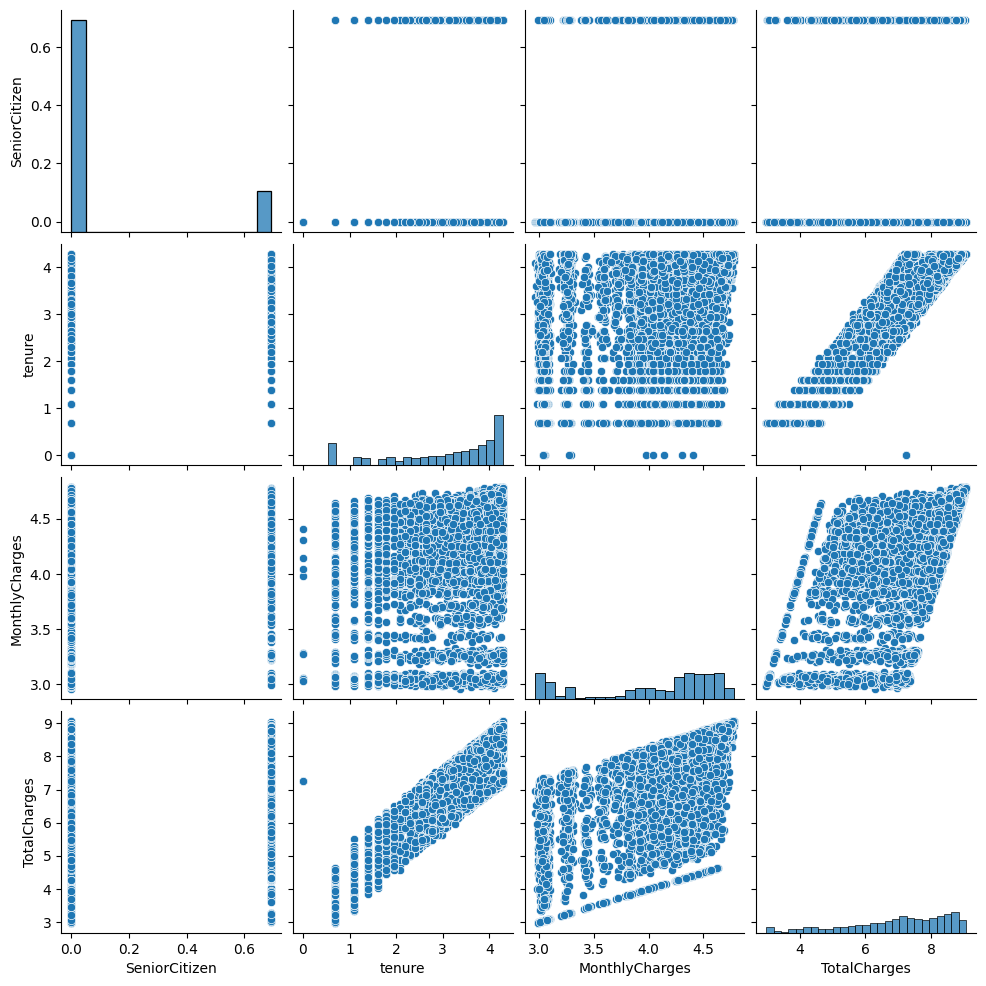

In [20]:
sns.pairplot(df[n_column])

normalizing dataset

In [21]:
scaler=MinMaxScaler()

In [22]:
df[n_column]=scaler.fit_transform(df[n_column])

In [33]:
df['Churn_Yes'].value_counts()

,count
Churn_Yes,
0,5174
1,1869


oversampling the churn feature(as there is an imbalance in the churn classes) and preparing the data for training.

In [23]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']
ros=RandomOverSampler()
X,y=ros.fit_resample(X,y)
x_train,x_test,y_train,y_test=train_test_split(X, y, test_size=0.2,random_state=42,shuffle=True)

fitting models with the data

In [24]:
model=LogisticRegression()
rfmodel=RandomForestClassifier()
xgmodel=XGBClassifier()
gbmodel=GradientBoostingClassifier()

In [25]:
model.fit(x_train,y_train)
rfmodel.fit(x_train,y_train)
xgmodel.fit(x_train,y_train)
gbmodel.fit(x_train,y_train)

GradientBoostingClassifier()

Testing Models

In [26]:
y_pred=model.predict(x_test)
yrf_pred=rfmodel.predict(x_test)
yxg_pred=xgmodel.predict(x_test)
ygb_pred=gbmodel.predict(x_test)

In [27]:
print(f"AOC ROC Score for Logistic Regression:{roc_auc_score(y_test,y_pred)}")
print(f"AOC ROC Score for Random Forest Classifier:{roc_auc_score(y_test,yrf_pred)}")
print(f"AOC ROC Score for XGBoost Classifier:{roc_auc_score(y_test,yxg_pred)}")
print(f"AOC ROC Score for Gradient Boosting Classifier:{roc_auc_score(y_test,ygb_pred)}")

AOC ROC Score for Logistic Regression:0.7792253991255138
AOC ROC Score for Random Forest Classifier:0.899811302961918
AOC ROC Score for XGBoost Classifier:0.8643103968239889
AOC ROC Score for Gradient Boosting Classifier:0.792251657051303


In [29]:
print(classification_report(y_test,yrf_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1021
           1       0.87      0.95      0.91      1049

    accuracy                           0.90      2070
   macro avg       0.90      0.90      0.90      2070
weighted avg       0.90      0.90      0.90      2070



Random forest model is fitting best on the dataset with correct prediction 0f 90% in 2070 samples